**Create images based on text prompts using a text-to-image model to explore Transformer
capabilities in multimodal tasks.**



## 1. Problem Statement (PS)

Traditional computer vision models were often limited to single-task labels (e.g., identifying a "dog" in a photo). However, human creativity is **multimodal**, bridging the gap between abstract linguistic concepts and complex visual synthesis. The challenge lies in developing a system that can interpret nuanced natural language prompts and generate high-fidelity, spatially coherent images that do not exist in a training database but are synthesized "on the fly."

## 2. Objectives

* **Demonstrate Multimodal Synergy:** To observe how Transformer-based text encoders (CLIP) can guide generative vision models (Diffusion).
* **Evaluate Latent Diffusion:** To implement and analyze the process of "denoising" random Gaussian noise into structured imagery.
* **Parameter Optimization:** To understand the impact of hyperparameters like `num_inference_steps` and `guidance_scale` on the final visual output.
* **Practical Implementation:** To successfully deploy a pre-trained `StableDiffusionPipeline` using the Hugging Face `diffusers` library in a GPU-accelerated environment.

---

## 3. Methodology

The implementation followed a four-phase technical pipeline:

1. **Environment Setup:** Integration of the `diffusers` and `transformers` libraries. The model was loaded in `float16` precision to optimize VRAM usage on the GPU.
2. **Text Encoding (The Transformer Phase):** The input prompt was tokenized and passed through a **Frozen CLIP Text Encoder**. This converted the string into a high-dimensional embedding (a mathematical representation of the prompt's meaning).
3. **Iterative Denoising (The Diffusion Phase):** * Starting with a latent canvas of pure noise.
* Using a **U-Net architecture** to predict and subtract noise at each step.
* Applying **Cross-Attention** to ensure the U-Net's "denoising" was constantly aligned with the Transformer's text embeddings.


4. **Image Reconstruction:** The final latent representation was passed through a **VAE (Variational Autoencoder) Decoder** to convert the mathematical tensors into an actual RGB image.

---

## 4. Conclusion

The practical successfully demonstrated the power of **Transformer-based multimodal learning**.


In [1]:
pip install diffusers transformers accelerate torch

In [2]:
import torch
from diffusers import StableDiffusionPipeline
from PIL import Image

# 1. Load the pre-trained model
# We use float16 to save memory (requires a GPU)
model_id = "runwayml/stable-diffusion-v1-5"
pipe = StableDiffusionPipeline.from_pretrained(model_id, torch_dtype=torch.float16)

# 2. Move the model to the GPU
pipe = pipe.to("cuda")

# 3. Define your prompt
prompt = "A futuristic city with floating gardens and neon waterfalls, high detail, 8k"

# 4. Run the generator
# num_inference_steps: higher = better quality but slower (standard is 30-50)
image = pipe(prompt, num_inference_steps=30).images[0]

# 5. Save and view the result
image.save("generated_city.png")
image.show()

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model_index.json:   0%|          | 0.00/541 [00:00<?, ?B/s]

Fetching 15 files:   0%|          | 0/15 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

StableDiffusionSafetyChecker LOAD REPORT from: /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-v1-5/snapshots/451f4fe16113bff5a5d2269ed5ad43b0592e9a14/safety_checker
Key                                               | Status     |  | 
--------------------------------------------------+------------+--+-
vision_model.vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

CLIPTextModel LOAD REPORT from: /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-v1-5/snapshots/451f4fe16113bff5a5d2269ed5ad43b0592e9a14/text_encoder
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  0%|          | 0/30 [00:00<?, ?it/s]

In [3]:
# Set a seed for reproducibility (using the same seed + same prompt = same image)
generator = torch.Generator("cuda").manual_seed(42)

image = pipe(
    prompt="A cyberpunk samurai standing in the rain, cinematic lighting, 8k",
    generator=generator,
    guidance_scale=8.5, # Range 1-20. Higher = follows prompt more strictly
    num_inference_steps=50 # More steps usually means better detail
).images[0]

image.save("samurai.png")

  0%|          | 0/50 [00:00<?, ?it/s]

In [4]:
from diffusers import StableDiffusionImg2ImgPipeline
import requests
from io import BytesIO

# 1. Switch to the Img2Img pipeline (it shares the same weights)
pipe_i2i = StableDiffusionImg2ImgPipeline.from_pretrained(
    model_id,
    torch_dtype=torch.float16
).to("cuda")

# 2. Load an initial image (you can also upload one to Colab)
url = "https://raw.githubusercontent.com/CompVis/stable-diffusion/main/assets/stable-samples/img2img/sketch-mountains-input.jpg"
response = requests.get(url)
init_image = Image.open(BytesIO(response.content)).convert("RGB")
init_image = init_image.resize((512, 512))

# 3. Generate a new version based on the sketch
# strength: 0.0 to 1.0.
# 0.0 = exact same image. 1.0 = completely ignores the original image.
prompt = "A professional oil painting of snowy mountains at sunrise"
images = pipe_i2i(prompt=prompt, image=init_image, strength=0.75, guidance_scale=7.5).images
images[0].save("transformed_mountains.png")

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

StableDiffusionSafetyChecker LOAD REPORT from: /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-v1-5/snapshots/451f4fe16113bff5a5d2269ed5ad43b0592e9a14/safety_checker
Key                                               | Status     |  | 
--------------------------------------------------+------------+--+-
vision_model.vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

CLIPTextModel LOAD REPORT from: /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-v1-5/snapshots/451f4fe16113bff5a5d2269ed5ad43b0592e9a14/text_encoder
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  0%|          | 0/37 [00:00<?, ?it/s]

In [5]:
neg_prompt = "blurry, distorted, low quality, extra limbs, ugly, text, watermark"

image = pipe(
    prompt="A futuristic laboratory with glowing chemicals",
    negative_prompt=neg_prompt
).images[0]

  0%|          | 0/50 [00:00<?, ?it/s]

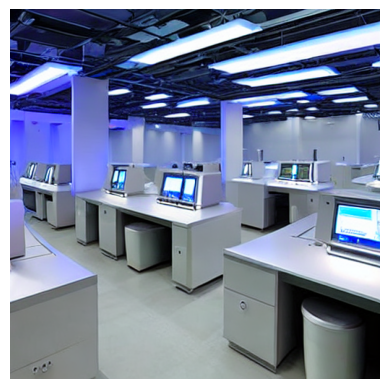

In [6]:
import matplotlib.pyplot as plt

plt.imshow(image)
plt.axis('off') # Hide the x/y numbers
plt.show()

  0%|          | 0/50 [00:00<?, ?it/s]

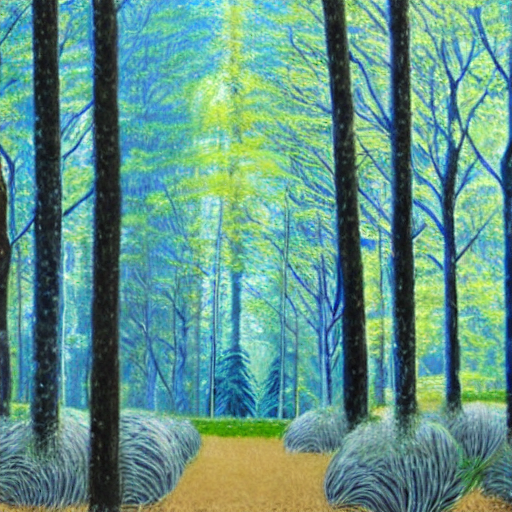

In [7]:
# This tells the Transformer to pay 50% more attention to 'blue'
prompt = "A (blue:1.5) forest with silver trees"
image = pipe(prompt).images[0]
image